In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("house_missing_val.csv")

In [4]:
df.shape

(20047, 29)

In [5]:
df.head()

,society,bedrooms,baths,rooms,link,floors,price,area,area_sqft,kitchens,...,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score,agePossession,has_servant_room
0,DHA Defence,6.0,6.0,"{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,19.75,40.0,10890.04,2.0,...,1,1,0,0,0,1,66,25,New Property,1
1,DHA Defence,6.0,7.0,"{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,11.50,20.0,5445.02,3.0,...,1,1,0,0,0,1,66,25,New Property,1
2,DHA Defence,6.0,7.0,"{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,28.50,40.0,10890.04,3.0,...,1,1,0,0,0,0,66,25,New Property,1
3,DHA Defence,5.0,6.0,"{'Bedrooms': '5', 'Bathrooms': '5', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,9.25,20.0,5445.02,3.0,...,1,1,0,0,0,1,66,25,New Property,1
4,DHA Defence,5.0,6.0,"{'Bedrooms': '2', 'Bathrooms': '2', 'Servant Q...",https://www.zameen.com/Property/dha_phase_7_dh...,2.0,7.15,20.0,5445.02,1.0,...,1,1,0,1,0,1,66,25,New Property,1


In [6]:
df.drop(columns=['rooms'], inplace=True)

In [7]:
df.head()

,society,bedrooms,baths,link,floors,price,area,area_sqft,kitchens,store_rooms,...,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score,agePossession,has_servant_room
0,DHA Defence,6.0,6.0,https://www.zameen.com/Property/dha_defence_dh...,2.0,19.75,40.0,10890.04,2.0,2.0,...,1,1,0,0,0,1,66,25,New Property,1
1,DHA Defence,6.0,7.0,https://www.zameen.com/Property/dha_defence_dh...,2.0,11.50,20.0,5445.02,3.0,2.0,...,1,1,0,0,0,1,66,25,New Property,1
2,DHA Defence,6.0,7.0,https://www.zameen.com/Property/dha_defence_dh...,2.0,28.50,40.0,10890.04,3.0,1.0,...,1,1,0,0,0,0,66,25,New Property,1
3,DHA Defence,5.0,6.0,https://www.zameen.com/Property/dha_defence_dh...,2.0,9.25,20.0,5445.02,3.0,1.0,...,1,1,0,0,0,1,66,25,New Property,1
4,DHA Defence,5.0,6.0,https://www.zameen.com/Property/dha_phase_7_dh...,2.0,7.15,20.0,5445.02,1.0,1.0,...,1,1,0,1,0,1,66,25,New Property,1


In [8]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors', 'price', 'area',
       'area_sqft', 'kitchens', 'store_rooms', 'price_per_sqft',
       'drawing_room', 'dining_room', 'lounge_or_sitting_room', 'laundry_room',
       'study_room', 'prayer_room', 'powder_room', 'gym', 'steam_room',
       'servant_quarters_flag', 'store_rooms_flag', 'kitchens_flag',
       'other_rooms', 'luxury_score', 'furnishing_score', 'agePossession',
       'has_servant_room'],
      dtype='object')

In [9]:
train_df=df.drop(columns=[
    'link',                     # useless identifier
    'society',                  # you chose not to use location
    'area',                     # already converted to area_sqft
    'servant_quarters_flag',    # duplicate info
    'store_rooms_flag',         # duplicate info
    'kitchens_flag',            # duplicate info
    'other_rooms',               # raw / vague
    'price_per_sqft'
])

In [10]:
train_df.head()

,bedrooms,baths,floors,price,area_sqft,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,luxury_score,furnishing_score,agePossession,has_servant_room
0,6.0,6.0,2.0,19.75,10890.04,2.0,2.0,1,1,1,1,1,1,1,1,1,66,25,New Property,1
1,6.0,7.0,2.0,11.50,5445.02,3.0,2.0,1,1,1,1,1,1,1,1,1,66,25,New Property,1
2,6.0,7.0,2.0,28.50,10890.04,3.0,1.0,1,1,1,1,1,1,1,1,1,66,25,New Property,1
3,5.0,6.0,2.0,9.25,5445.02,3.0,1.0,1,1,1,1,1,1,1,1,1,66,25,New Property,1
4,5.0,6.0,2.0,7.15,5445.02,1.0,1.0,1,1,1,1,1,1,1,1,1,66,25,New Property,1


In [11]:
train_df.columns

Index(['bedrooms', 'baths', 'floors', 'price', 'area_sqft', 'kitchens',
       'store_rooms', 'drawing_room', 'dining_room', 'lounge_or_sitting_room',
       'laundry_room', 'study_room', 'prayer_room', 'powder_room', 'gym',
       'steam_room', 'luxury_score', 'furnishing_score', 'agePossession',
       'has_servant_room'],
      dtype='object')

<Axes: xlabel='luxury_score'>

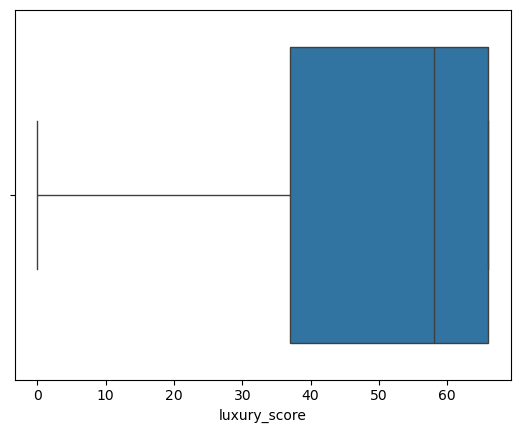

In [12]:
sns.boxplot(x=df['luxury_score'])

In [13]:
dict(train_df['luxury_score'].value_counts())

{66: np.int64(6963),
 62: np.int64(976),
 0: np.int64(790),
 60: np.int64(653),
 4: np.int64(618),
 19: np.int64(548),
 57: np.int64(499),
 54: np.int64(482),
 58: np.int64(442),
 63: np.int64(387),
 61: np.int64(327),
 49: np.int64(320),
 23: np.int64(290),
 38: np.int64(289),
 51: np.int64(269),
 53: np.int64(255),
 52: np.int64(253),
 64: np.int64(247),
 44: np.int64(246),
 50: np.int64(224),
 55: np.int64(218),
 65: np.int64(202),
 59: np.int64(199),
 48: np.int64(199),
 46: np.int64(183),
 56: np.int64(181),
 35: np.int64(177),
 45: np.int64(175),
 37: np.int64(151),
 47: np.int64(147),
 33: np.int64(143),
 41: np.int64(133),
 31: np.int64(130),
 43: np.int64(128),
 42: np.int64(121),
 15: np.int64(120),
 9: np.int64(115),
 32: np.int64(112),
 29: np.int64(107),
 40: np.int64(104),
 39: np.int64(104),
 7: np.int64(100),
 36: np.int64(96),
 16: np.int64(95),
 26: np.int64(94),
 28: np.int64(94),
 27: np.int64(91),
 22: np.int64(89),
 20: np.int64(88),
 34: np.int64(81),
 13: np.int

In [14]:
q1 = train_df['luxury_score'].quantile(0.25)
q2 = train_df['luxury_score'].quantile(0.50)
q3 = train_df['luxury_score'].quantile(0.75)

def categorize_luxury(score):
    if score < q1:
        return "Low"
    elif score < q2:
        return "Medium"
    elif score < q3:
        return "High"
    else:
        return "Very High"


In [15]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: xlabel='floors'>

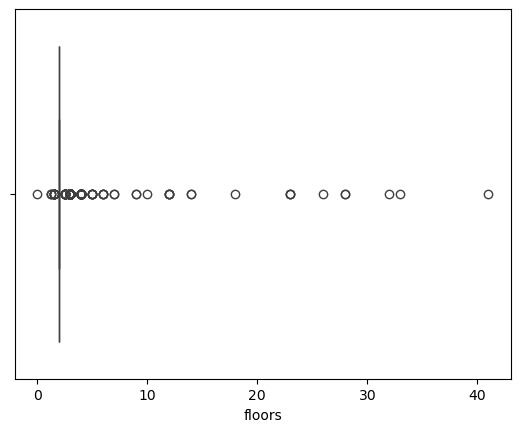

In [16]:
sns.boxplot(x=df['floors'])

In [17]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif floor >= 11:
        return "High Floor"
    else:
        return None

train_df['floor_category'] = train_df['floors'].apply(categorize_floor)

In [18]:
train_df['floor_category'].value_counts()

floor_category
Low Floor     18060
Mid Floor      1939
High Floor       16
Name: count, dtype: int64

In [19]:
train_df.drop(columns=['floors', 'luxury_score'], inplace=True)

In [20]:
train_df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'drawing_room', 'dining_room', 'lounge_or_sitting_room', 'laundry_room',
       'study_room', 'prayer_room', 'powder_room', 'gym', 'steam_room',
       'furnishing_score', 'agePossession', 'has_servant_room',
       'luxury_category', 'floor_category'],
      dtype='object')

In [21]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()

categorical_cols = data_label_encoded.select_dtypes(include=['object']).columns

oe = OrdinalEncoder()
data_label_encoded[categorical_cols] = oe.fit_transform(data_label_encoded[categorical_cols])

X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

In [22]:
X_label

,bedrooms,baths,area_sqft,kitchens,store_rooms,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,furnishing_score,agePossession,has_servant_room,luxury_category,floor_category
0,6.0,6.0,10890.04,2.0,2.0,1,1,1,1,1,1,1,1,1,25,1.0,1,3.0,1.0
1,6.0,7.0,5445.02,3.0,2.0,1,1,1,1,1,1,1,1,1,25,1.0,1,3.0,1.0
2,6.0,7.0,10890.04,3.0,1.0,1,1,1,1,1,1,1,1,1,25,1.0,1,3.0,1.0
3,5.0,6.0,5445.02,3.0,1.0,1,1,1,1,1,1,1,1,1,25,1.0,1,3.0,1.0
4,5.0,6.0,5445.02,1.0,1.0,1,1,1,1,1,1,1,1,1,25,1.0,1,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20042,6.0,7.0,5445.02,2.0,1.0,1,1,1,1,0,0,0,0,0,25,3.0,1,2.0,1.0
20043,4.0,5.0,5445.02,2.0,2.0,1,1,0,1,0,0,1,0,0,15,4.0,1,2.0,1.0
20044,6.0,6.0,5445.02,2.0,1.0,1,1,1,1,1,1,1,1,1,25,0.0,1,3.0,1.0
20045,5.0,6.0,5445.02,3.0,2.0,1,1,0,0,1,1,0,0,0,8,3.0,1,2.0,1.0


## 8 feature selection techniques

## Technique 1: Correlation Analysis

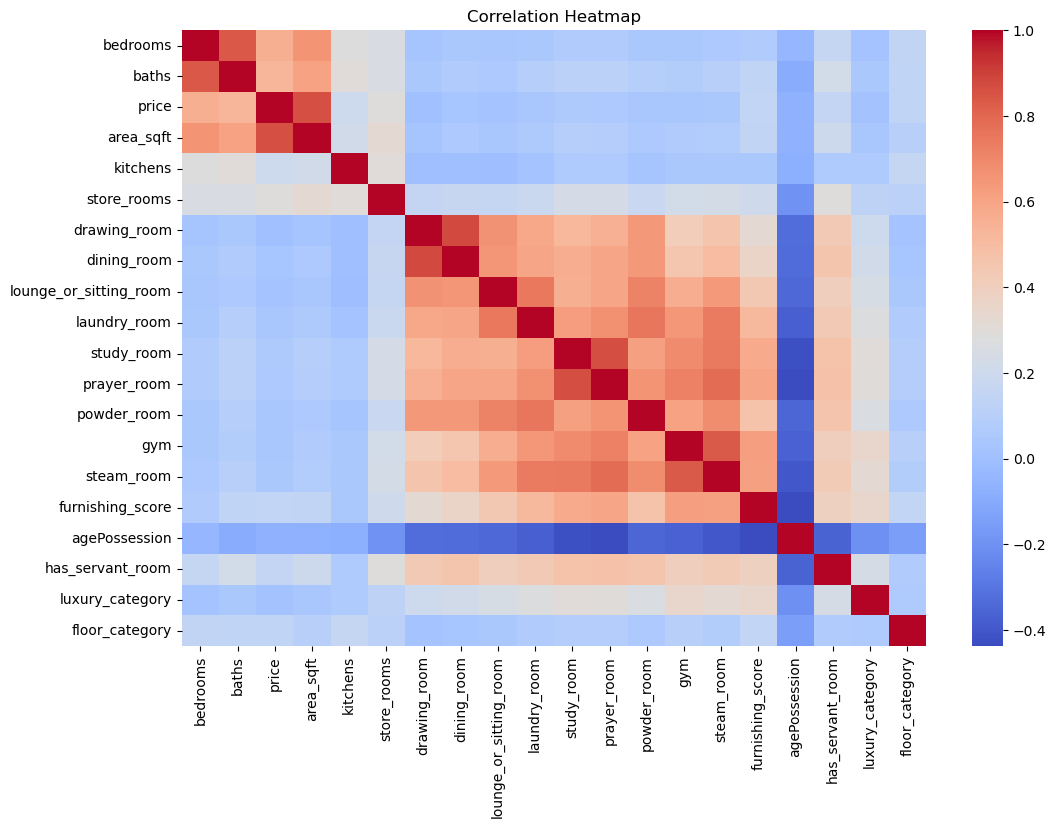

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(data_label_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index': 'feature', 'price': 'corr_coeff'})
fi_df1.sort_values(by='corr_coeff', ascending=False)

,feature,corr_coeff
1,price,1.000000
2,area_sqft,0.863776
0,baths,0.531689
4,store_rooms,0.287232
3,kitchens,0.200276
16,has_servant_room,0.156105
14,furnishing_score,0.146579
18,floor_category,0.138768
9,study_room,0.057162
10,prayer_room,0.056140


### 📌 Technique 2: Random Forest Feature Importance


In [25]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
2,area_sqft,0.811004
14,furnishing_score,0.027604
0,bedrooms,0.025464
15,agePossession,0.022033
1,baths,0.020912
17,luxury_category,0.017258
3,kitchens,0.016408
4,store_rooms,0.012716
18,floor_category,0.009464
16,has_servant_room,0.007623


### 📌 Technique 3: Gradient Boosting Feature Importance


In [26]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Train Gradient Boosting Regressor
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
2,area_sqft,0.947022
1,baths,0.017983
14,furnishing_score,0.008232
0,bedrooms,0.006203
15,agePossession,0.005799
18,floor_category,0.005638
12,gym,0.001847
3,kitchens,0.001843
17,luxury_category,0.001814
4,store_rooms,0.001583


### 📌 Technique 3: Gradient Boosting Feature Importance

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Train Gradient Boosting Regressor
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
2,area_sqft,0.947054
1,baths,0.017966
14,furnishing_score,0.008206
0,bedrooms,0.006229
15,agePossession,0.005801
18,floor_category,0.005614
12,gym,0.001847
3,kitchens,0.001846
17,luxury_category,0.001816
4,store_rooms,0.001586


### 📌 Technique 4: Permutation Importance

Permutation Importance measures how much a model’s performance decreases when a feature’s values are randomly shuffled.  
If shuffling a feature significantly reduces model performance, that feature is important.


In [28]:

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train-test split
X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(
    X_label, y_label, test_size=0.2, random_state=42
)

# Train model
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Compute permutation importance
perm_importance = permutation_importance(
    rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42
)

# Store results
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
2,area_sqft,1.368947
0,bedrooms,0.049235
1,baths,0.036987
15,agePossession,0.032616
14,furnishing_score,0.028996
17,luxury_category,0.011508
3,kitchens,0.007439
4,store_rooms,0.007398
18,floor_category,0.005586
12,gym,0.004353


### 📌 Technique 5: LASSO (Feature Selection)

LASSO (L1 Regularization) helps in feature selection by shrinking less important feature coefficients to zero.


In [29]:

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train LASSO model
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
2,area_sqft,5.140647
14,furnishing_score,0.356352
18,floor_category,0.301229
1,baths,0.160670
4,store_rooms,0.050888
3,kitchens,0.041482
11,powder_room,0.021509
8,laundry_room,0.000000
7,lounge_or_sitting_room,0.000000
5,drawing_room,-0.000000


### 📌 Technique 6: RFE (Recursive Feature Elimination)

RFE selects important features by recursively removing the least important ones based on a model.


In [30]:

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Initialize model
estimator = RandomForestRegressor()

# Apply RFE
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get selected features
selected_features = X_label.columns[selector_label.support_]

# Get importance scores
selected_coefficients = selector_label.estimator_.feature_importances_

# Store results
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
2,area_sqft,0.810228
14,furnishing_score,0.027549
0,bedrooms,0.025656
15,agePossession,0.022349
1,baths,0.020714
17,luxury_category,0.017385
3,kitchens,0.016280
4,store_rooms,0.012898
18,floor_category,0.009576
16,has_servant_room,0.007564


### 📌 Technique 7: Linear Regression Weights

Linear Regression assigns coefficients (weights) to each feature, indicating their impact on the target variable.

In [31]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
2,area_sqft,5.162340
14,furnishing_score,0.379746
18,floor_category,0.309114
1,baths,0.219194
4,store_rooms,0.062482
11,powder_room,0.052826
3,kitchens,0.049422
7,lounge_or_sitting_room,0.027566
6,dining_room,0.018553
8,laundry_room,0.009935


In [32]:
final_fi_df = fi_df1.merge(fi_df2, on='feature') \
                   .merge(fi_df3, on='feature') \
                   .merge(fi_df4, on='feature') \
                   .merge(fi_df5, on='feature') \
                   .merge(fi_df6, on='feature') \
                   .merge(fi_df7, on='feature') \
                   .set_index('feature')
                   
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
baths,0.531689,0.020912,0.017966,0.036987,0.160670,0.020714,0.219194
area_sqft,0.863776,0.811004,0.947054,1.368947,5.140647,0.810228,5.162340
kitchens,0.200276,0.016408,0.001846,0.007439,0.041482,0.016280,0.049422
store_rooms,0.287232,0.012716,0.001586,0.007398,0.050888,0.012898,0.062482
drawing_room,0.005721,0.001567,0.000443,0.000637,-0.000000,0.001455,-0.034293
dining_room,0.031094,0.001705,0.000022,-0.000778,-0.000000,0.001637,0.018553
lounge_or_sitting_room,0.018941,0.003369,0.000000,-0.000254,0.000000,0.003754,0.027566
laundry_room,0.039153,0.003250,0.000162,-0.000944,0.000000,0.003263,0.009935
study_room,0.057162,0.003061,0.000615,0.000301,-0.141276,0.003309,-0.146962


In [33]:
## normalize 
final_fi_df = final_fi_df.div(final_fi_df.sum(axis=0), axis=1)

In [34]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
area_sqft                 0.881828
baths                     0.021350
furnishing_score          0.021036
agePossession             0.018270
luxury_category           0.011258
kitchens                  0.010088
store_rooms               0.008201
floor_category            0.007226
gym                       0.004450
has_servant_room          0.004374
study_room                0.001839
steam_room                0.001815
lounge_or_sitting_room    0.001785
powder_room               0.001602
prayer_room               0.001596
laundry_room              0.001555
drawing_room              0.000993
dining_room               0.000733
dtype: float64

### model with all features

In [35]:
# with all the cols
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

scores.mean()

np.float64(0.6642246379539933)

In [36]:
drop_cols = [
    'study_room',
    'steam_room',
    'lounge_or_sitting_room',
    'powder_room',
    'prayer_room',
    'laundry_room',
    'drawing_room',
    'dining_room',
    'luxury_category'
]

# create new dataset
X_reduced = X_label.drop(columns=drop_cols)

# model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores_reduced = cross_val_score(rf, X_reduced, y_label, cv=5, scoring='r2')

scores_reduced.mean()

np.float64(0.656317079309104)

In [38]:
export_df = X_label.drop(columns=drop_cols)
export_df['price'] = y_label

export_df.to_csv('lahore_house_post_feature_selection.csv', index=False)

In [39]:
export_df.head()

,bedrooms,baths,area_sqft,kitchens,store_rooms,gym,furnishing_score,agePossession,has_servant_room,floor_category,price
0,6.0,6.0,10890.04,2.0,2.0,1,25,1.0,1,1.0,19.75
1,6.0,7.0,5445.02,3.0,2.0,1,25,1.0,1,1.0,11.50
2,6.0,7.0,10890.04,3.0,1.0,1,25,1.0,1,1.0,28.50
3,5.0,6.0,5445.02,3.0,1.0,1,25,1.0,1,1.0,9.25
4,5.0,6.0,5445.02,1.0,1.0,1,25,1.0,1,1.0,7.15
